# 1 — The Spectrum: Prompts → Chains → Workflows → Agents

**Course segment 1: Where simple RAG breaks down (35 min)**

This notebook sets the table for everything that follows. We:

1. Locate four common patterns on a single spectrum:
   - **Prompt** — one LLM call.
   - **Chain** — a fixed sequence of LLM / tool calls.
   - **Workflow** — a graph (DAG) of nodes with conditional routing and state.
   - **Agent** — a model that *chooses* which tool to call next, in a loop.
2. Build the simplest possible RAG (Chroma + MiniLM + one LLM call) and run it against an obviously multi-hop question on the heterogeneous corpus from the corpus notebook. Watch it fail.
3. Show the same question handled by the smallest possible LangGraph workflow (`retrieve -> generate -> END`), and discuss why even *that* won't be enough — motivating notebooks 2-5.
4. Run the failing query across **multiple OpenRouter models** to demonstrate that better-model-only is *not* a substitute for better-architecture.

**Prerequisites:** run `0_build_corpus.ipynb` once.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY"), "Set OPENROUTER_API_KEY in .env"

from corpus import load_chroma, load_gold_set
from llm import get_llm

chroma = load_chroma()
gold = load_gold_set()
print(f"Corpus: {chroma._collection.count()} chunks across 3 sources.")
print(f"Gold set: {len(gold)} questions.")

/Users/sinanozdemir/Teaching/Pearson/advanced-agentic-ai-in-three-weeks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6038.93it/s]


Corpus: 3689 chunks across 3 sources.
Gold set: 30 questions.


## The spectrum

| Pattern    | Control flow                       | Determinism      | Where it shines                     | Where it breaks                       |
|------------|------------------------------------|------------------|-------------------------------------|---------------------------------------|
| **Prompt** | One call                           | High             | Self-contained tasks                | Anything needing external info or > 1 step |
| **Chain**  | Fixed pipeline                     | High             | Known, repeatable sequences         | Branches you didn't anticipate        |
| **Workflow** | DAG with conditionals + state    | Medium-high      | Multi-step pipelines with quality gates and retries | Truly open-ended exploration          |
| **Agent**  | Model picks the next tool          | Low              | Open-ended, novel queries           | Reliability, cost predictability, debuggability |

Rule of thumb: **start with a prompt, escalate one rung only when failure is reliable**. Most "we need an agent" use cases are workflow-shaped.

Today's failure case — a 3-hop chain that requires evidence from multiple Wikipedia articles **and** a Beehiiv post, then synthesized into a coherent intellectual lineage — sits exactly at the boundary where a workflow earns its keep.

## Pattern 1 — A prompt with no retrieval

The model is asked the question with no help. Useful as a control: did retrieval add anything at all?

In [2]:
# An explicitly 3-hop question. Each numbered sub-question targets a
# different region of the corpus (Wikipedia: Hinton + Backprop + AlexNet,
# Beehiiv: 'Probing LLMs for a World Model'). This is a great failure case
# for naive single-shot RAG because k=4 retrieval can rarely fit all four
# threads, and even when it does, single-pass synthesis struggles to bridge
# them into a coherent lineage.
FAILURE_QUESTION = (
    "Trace the conceptual lineage from Geoffrey Hinton's 1980s work to a "
    "modern Beehiiv post on probing LLMs for a world model:\n"
    "  (1) Which learning algorithm did Hinton help popularize in the 1980s "
    "that became the foundation of modern neural network training?\n"
    "  (2) Which 2012 ImageNet breakthrough demonstrated the power of that "
    "algorithm at scale, and what role did Hinton play in it?\n"
    "  (3) How does the AI Office Hours 'Probing LLMs for a World Model' "
    "post extend that intellectual lineage by asking what scaled neural "
    "networks have learned?"
)

REFERENCE = (
    "(1) Backpropagation. Hinton co-authored the seminal 1986 paper that "
    "popularized backprop as the universal gradient-based training algorithm "
    "for multi-layer neural networks, restoring credibility to neural-network "
    "research after the perceptron-era stagnation.\n"
    "(2) AlexNet (2012). Hinton's group at Toronto (Krizhevsky, Sutskever, "
    "Hinton) trained a deep CNN with backpropagation on ImageNet and won by "
    "a wide margin, demonstrating that deep learning + GPUs could dominate "
    "large-scale computer vision and kicking off the modern deep-learning era.\n"
    "(3) The Beehiiv post extends the lineage by asking whether today's "
    "billion-parameter LLMs — trained with the same backprop algorithm Hinton "
    "popularized — have internalized implicit world models. It treats the "
    "question as the contemporary descendant of Hinton's long-running argument "
    "that distributed neural representations encode meaningful structure."
)

print("Question:")
print(FAILURE_QUESTION)
print("\nReference answer (what we'd love to see):")
print(REFERENCE)

Question:
Trace the conceptual lineage from Geoffrey Hinton's 1980s work to a modern Beehiiv post on probing LLMs for a world model:
  (1) Which learning algorithm did Hinton help popularize in the 1980s that became the foundation of modern neural network training?
  (2) Which 2012 ImageNet breakthrough demonstrated the power of that algorithm at scale, and what role did Hinton play in it?
  (3) How does the AI Office Hours 'Probing LLMs for a World Model' post extend that intellectual lineage by asking what scaled neural networks have learned?

Reference answer (what we'd love to see):
(1) Backpropagation. Hinton co-authored the seminal 1986 paper that popularized backprop as the universal gradient-based training algorithm for multi-layer neural networks, restoring credibility to neural-network research after the perceptron-era stagnation.
(2) AlexNet (2012). Hinton's group at Toronto (Krizhevsky, Sutskever, Hinton) trained a deep CNN with backpropagation on ImageNet and won by a wide

In [3]:
llm = get_llm("openai/gpt-5.4-nano")

answer_no_rag = llm.invoke(FAILURE_QUESTION).content
print("--- Answer without retrieval ---")
print(answer_no_rag)

--- Answer without retrieval ---
### Conceptual lineage (1980s → 2010s → today)
At a high level: Hinton’s 1980s work helped popularize the modern recipe for training deep neural nets (especially via backprop and related learning ideas). That lineage culminated in the 2012 ImageNet breakthrough showing that these methods scale. Today’s LLM probing posts (like AI Office Hours’ “Probing LLMs for a World Model”) extend the same tradition by asking not just *whether* large neural nets work, but *what internal “world-model-like” representations they have learned*—i.e., moving from capability to interpretation.

---

## (1) Which learning algorithm did Hinton help popularize in the 1980s that became foundational for modern neural network training?
**Backpropagation (backprop), i.e., the backpropagation algorithm for training multilayer neural networks.**

In the 1980s, Hinton was a major figure in making multi-layer neural networks and their training feasible/credible, and backprop became the

## Pattern 2 — A naive single-shot RAG chain

Retrieve top-k once, stuff into the prompt, generate. This is the RAG pipeline most teams ship as v1. It's a *chain*, not a workflow: no branching, no quality gate, no second look.

In [4]:
SIMPLE_RAG_PROMPT = """You are a helpful assistant. Answer the question using ONLY the provided context.
If the context is insufficient, say so explicitly.

Context:
{context}

Question: {question}

Answer:"""


def simple_rag(question: str, k: int = 4, model: str = "openai/gpt-5.4-nano") -> tuple[str, list]:
    docs = chroma.similarity_search(question, k=k)
    context = "\n\n---\n\n".join(
        f"[{d.metadata.get('source')}: {d.metadata.get('title','?')[:60]}]\n{d.page_content}"
        for d in docs
    )
    msg = SIMPLE_RAG_PROMPT.format(context=context, question=question)
    answer = get_llm(model).invoke(msg).content
    return answer, docs


answer_simple, retrieved = simple_rag(FAILURE_QUESTION, k=10)
print(f"Retrieved {len(retrieved)} chunks:")
for d in retrieved:
    print(f"  - [{d.metadata.get('source')}] {d.metadata.get('title','?')[:70]}")
print("\n--- Answer with simple RAG ---")
print(answer_simple)

Retrieved 10 chunks:
  - [wikipedia] Geoffrey Hinton
  - [wikipedia] Geoffrey Hinton
  - [wikipedia] Geoffrey Hinton
  - [wikipedia] Geoffrey Hinton
  - [wikipedia] Geoffrey Hinton
  - [wikipedia] Neural network (machine learning)
  - [wikipedia] Artificial intelligence
  - [wikipedia] Geoffrey Hinton
  - [wikipedia] History of artificial intelligence
  - [wikipedia] Neural network (machine learning)

--- Answer with simple RAG ---
Answer: The provided context is **not sufficient** to fully answer (3) as stated, because it does not include any information about the “Beehiiv post on probing LLMs for a world model” or the “AI Office Hours ‘Probing LLMs for a World Model’” post.

What the context **does** support:

1) **Which learning algorithm did Hinton help popularize in the 1980s that became the foundation of modern neural network training?**  
Hinton helped popularize the **backpropagation algorithm** for training multi-layer neural networks (with David Rumelhart and Ronald J. Willia

### Look at *which* chunks came back

The query mentions Geoffrey Hinton by name, so dense retrieval over-indexes on the Hinton bio — top results are dominated by `Geoffrey Hinton` chunks plus generic NN/AI articles. Mapped against the three hops the question asks for:

| Hop | What we'd need | What we got |
| :-- | :-- | :-- |
| **1.** Backprop algorithm | `Backpropagation` or `Geoffrey Hinton` chunks | ✅ surfaced (lots of Hinton) |
| **2.** AlexNet 2012 ImageNet | `AlexNet` chunks | ❌ **zero retrieved** |
| **3.** "Probing LLMs for a World Model" Beehiiv post | `beehiiv` chunks for that post | ❌ **zero retrieved** |

Now read the answer: hops 2 and 3 are stated with the same fluent confidence as hop 1, but the model had **no evidence** for them. Hop 2 (AlexNet) is correct only because the model knows it from pretraining — a correct answer with zero supporting evidence is still a faithfulness failure, and breaks on facts not in pretraining. Hop 3 (the Beehiiv post) is **fabricated**: notice it says nothing the post specifically argues, just vague linkage. This is naive RAG's most dangerous failure mode — a confident, plausible answer that hides the missing evidence. The rubric catches it (faithfulness ≪ correctness); a casual eyeball won't. The second, third, and fifth notebooks each fix one piece: query decomposition retrieves each hop separately; hybrid + grading uses BM25 to catch literal terms like "AlexNet" and drops irrelevant Hinton chunks; gap analysis notices the Beehiiv evidence is missing and retries.

### Why does simple RAG fail here?

The question is genuinely **3-hop** — backprop, AlexNet, and the Beehiiv post each live in a different corner of the corpus. Naive RAG fails for four stacked reasons: a **single retrieval pass** for the whole question skews toward whichever sub-question dominates the embedding; **k is too small** (k=10 on a 3-hop question needs 6–9 chunks diversified across sources, not 10 chunks of one article); there's **no grade or gate**, so the model answers with whatever it got and hallucinates or hedges the missing thread; and there's **no iteration**, so the model can't say "I have hops 1 and 2 but not hop 3, fetch more."

These four failure modes are exactly what query decomposition (the second notebook), hybrid search + grading (the third), and adaptive iteration (the fifth) fix.

But before we go there: is the architectural problem actually a *model* problem? Maybe a bigger / smarter / reasoning model rescues simple RAG?

## Multi-model: does throwing a smarter model at simple RAG fix it?

Same retrieval, same prompt — but we walk **OpenAI's own evolution** from May 2023 to March 2026. Holding the vendor fixed isolates each model's *alignment generation* (its refusal-training recipe) as the variable.

| Released | Model | Era |
|---|---|---|
| 2023-05 | `gpt-3.5-turbo` | pre-refusal-training; happily fills gaps from pretraining |
| 2024-07 | `gpt-4o-mini` | 4o generation; somewhat aligned but still inclined to "help" |
| 2025-04 | `gpt-4.1-mini` | 4.1 generation; refusal behavior more reliable |
| 2025-08 | `gpt-5-mini`   | first GPT-5; refusal-on-missing-evidence is default |
| 2026-03 | `gpt-5.4-nano` | current cheap workhorse |

Predict a U-curve, not a monotone trend: 2023 models are blunt refusers (high faithfulness for the wrong reason — they barely said anything); the 2024–mid-2025 "helpful" generation confidently fills missing hops from pretraining (highest `overall`, mediocre faithfulness); GPT-5+ refuses when evidence is missing (high faithfulness honestly earned, lower completeness). The lesson: **faithfulness alone can't tell the 2023 and 2026 cases apart** — both score 5 — and three years of alignment never moved the architectural ceiling because retrieval still missed two-thirds of the evidence.

**Rubric note**: we pass retrieved chunks as `evidence=` to `judge_with_rubric` so faithfulness is scored *against the retrieval*, not the reference. Otherwise every model trivially scores 5 because the judge can't tell "answered from evidence" from "answered from training data" — the exact failure mode RAG is supposed to prevent.

In [10]:
from judges import judge_with_rubric

# A chronological "evolution timeline" within a single vendor. Holding the
# vendor (OpenAI) fixed removes the "different lab, different recipe"
# confound — what's left to vary is each model's *alignment generation*.
# Pre-refusal-training, models confabulated missing evidence; modern
# alignment teaches them to decline. We mix pre- and post-alignment-refresh
# models to show the progression visually.
ROSTER = [
    ("openai/gpt-3.5-turbo", "2023-05"),   # early OpenAI model
    ("openai/gpt-4o-mini",   "2024-07"),   # 4o generation, mid alignment
    ("openai/gpt-4.1-mini",  "2025-04"),   # 4.1 generation
    ("openai/gpt-5-mini",    "2025-08"),   # first GPT-5
    ("openai/gpt-5.4-mini",  "2026-03"),   # current cheap workhorse
]

results = []
for slug, released in ROSTER:
    print(f"=== {slug}  ({released}) ===")
    answer, retrieved = simple_rag(FAILURE_QUESTION, k=4, model=slug)
    # Pass the retrieved chunks as evidence so faithfulness is scored
    # *against the retrieval*, not just against the reference answer.
    # Without this, a model that fabricates correct-from-pretraining
    # facts gets faithfulness=5 — defeating the whole point.
    evidence = [d.page_content for d in retrieved]
    rubric = judge_with_rubric(FAILURE_QUESTION, answer, REFERENCE, evidence=evidence)
    results.append({
        "released": released,
        "model": slug,
        "overall": rubric.overall,
        "faithfulness": rubric.faithfulness,
        "correctness": rubric.correctness,
        "completeness": rubric.completeness,
        "answer": answer,
        "judge_notes": rubric.notes,
    })
    print(
        f"  overall={rubric.overall:.2f}  "
        f"faithfulness={rubric.faithfulness}  "
        f"correctness={rubric.correctness}  "
        f"completeness={rubric.completeness}"
    )
    print(f"  notes: {rubric.notes[:240]}\n")

import pandas as pd
pd.DataFrame(results)[["released", "model", "overall", "faithfulness", "correctness", "completeness"]]

=== openai/gpt-3.5-turbo  (2023-05) ===
  overall=1.67  faithfulness=5  correctness=0  completeness=0
  notes: The candidate refuses to answer, claiming no information is available. However, the evidence clearly supports part (1) — backpropagation applied to multi-layer networks by Rumelhart, Hinton, and Williams — so a partial answer was possible. 

=== openai/gpt-4o-mini  (2024-07) ===
  overall=3.50  faithfulness=3  correctness=4  completeness=3
  notes: Part (1) is correct and grounded in the evidence (Rumelhart/Hinton/Williams backprop). Part (2) is factually correct per the reference but NOT supported by the evidence chunks — AlexNet/ImageNet/2012 are never mentioned, so this is pretrain

=== openai/gpt-4.1-mini  (2025-04) ===
  overall=3.60  faithfulness=3  correctness=4  completeness=4
  notes: Part (1) is well-grounded in the evidence. Part (2) correctly notes the evidence is insufficient but then fills in from pretraining knowledge (AlexNet details, Hinton's role) without fla

,released,model,overall,faithfulness,correctness,completeness
0,2023-05,openai/gpt-3.5-turbo,1.67,5,0,0
1,2024-07,openai/gpt-4o-mini,3.50,3,4,3
2,2025-04,openai/gpt-4.1-mini,3.60,3,4,4
3,2025-08,openai/gpt-5-mini,3.00,5,2,2
4,2026-03,openai/gpt-5.4-mini,3.30,5,3,2


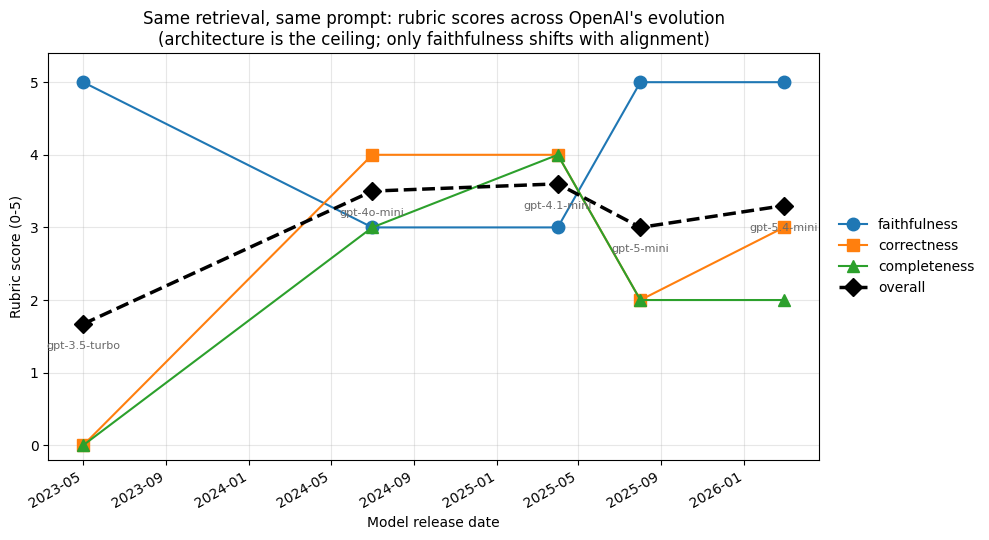

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(results)
df["release_date"] = pd.to_datetime(df["released"], format="%Y-%m")
df = df.sort_values("release_date").reset_index(drop=True)

METRICS = [
    ("faithfulness", "tab:blue",   "o"),
    ("correctness",  "tab:orange", "s"),
    ("completeness", "tab:green",  "^"),
    ("overall",      "black",      "D"),
]

fig, ax = plt.subplots(figsize=(10, 5.5))
for metric, color, marker in METRICS:
    lw = 2.5 if metric == "overall" else 1.5
    ls = "--" if metric == "overall" else "-"
    ax.plot(df["release_date"], df[metric], marker=marker, color=color,
            linewidth=lw, linestyle=ls, markersize=9, label=metric)

# Label each point with its model slug (short form).
for _, row in df.iterrows():
    short = row["model"].split("/")[-1]
    ax.annotate(short, (row["release_date"], row["overall"]),
                xytext=(0, -18), textcoords="offset points",
                ha="center", fontsize=8, color="dimgray")

ax.set_xlabel("Model release date")
ax.set_ylabel("Rubric score (0-5)")
ax.set_title("Same retrieval, same prompt: rubric scores across OpenAI's evolution\n"
             "(architecture is the ceiling; only faithfulness shifts with alignment)")
ax.set_ylim(-0.2, 5.4)
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### What the scores tell us

Reading the chart with release date on the x-axis, three things show up. **(1)** The black `overall` line stays in the 1.5–4 band across three years of OpenAI progress — *no model can synthesize evidence it never received*, so retrieval is the ceiling, not model size. **(2)** There are **three alignment eras**, not two:

| Era | Models | Behavior on partial evidence | Score signature |
|---|---|---|---|
| **Blunt refuser (2023)** | `gpt-3.5-turbo` | Refuses everything, even hops it has evidence for. | `faithfulness=5`, `correctness≈0`, lowest `overall` |
| **Helpful confabulator (mid-2024 → mid-2025)** | `gpt-4o-mini`, `gpt-4.1-mini` | Quietly fills missing hops from pretraining. | `correctness`/`completeness` peak; `faithfulness` dips to 3; *highest* `overall` |
| **Cautious refuser (mid-2025 onward)** | `gpt-5-mini`, `gpt-5.4-mini` | Answers grounded hops, explicitly declines the rest. | `faithfulness=5` earned honestly; `completeness` drops; `overall` ~3 |

**(3) Faithfulness alone is not enough.** The 2023 refuser and the 2026 cautious answerer both score `faithfulness=5`, but `overall` is 1.67 vs 3.3 — saying nothing is *technically* faithful, just useless. The middle era is dangerous in the opposite direction: it tops `overall` precisely because it confabulates pretraining facts the judge then rewards. Run this on private docs or post-training events and that same model is silently, confidently wrong — which is why the third notebook adds CRAG-style grading and the fifth adds gap-analysis re-retrieval.

## Pattern 3 — The smallest possible LangGraph workflow

Now we lift the simple chain into a `StateGraph`. The graph is still trivial — `retrieve -> generate -> END` — but it gives us:
- **Explicit state** that the next notebook will extend.
- A `mermaid` rendering students can read.
- A place to bolt on the next nodes (grading, gap analysis, ...).

It's not better yet — same retrieval, same prompt — but it's the right *shape* for everything that follows.

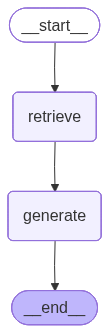

In [6]:
from typing import TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END


class RAGState(TypedDict):
    question: str
    docs: list[Document]
    answer: str


def retrieve_node(state: RAGState) -> dict:
    docs = chroma.similarity_search(state["question"], k=4)
    return {"docs": docs}


def generate_node(state: RAGState) -> dict:
    context = "\n\n---\n\n".join(d.page_content for d in state["docs"])
    msg = SIMPLE_RAG_PROMPT.format(context=context, question=state["question"])
    return {"answer": llm.invoke(msg).content}


graph = StateGraph(RAGState)
graph.add_node("retrieve", retrieve_node)
graph.add_node("generate", generate_node)
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)
simple_workflow = graph.compile()

try:
    from IPython.display import Image, display
    display(Image(simple_workflow.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("(graph rendering needs mermaid + pyppeteer; skipping)", exc)
    print(simple_workflow.get_graph().draw_ascii())

In [7]:
result = simple_workflow.invoke({"question": FAILURE_QUESTION, "docs": [], "answer": ""})
print("--- Workflow answer ---")
print(result["answer"])

--- Workflow answer ---
The provided context is enough to answer (1) and (3) at a high level, but it is insufficient to answer (2) (it contains no information about any 2012 ImageNet breakthrough, nor Hinton’s role in it).

1) **Which learning algorithm did Hinton help popularize in the 1980s that became the foundation of modern neural network training?**  
Hinton helped popularize **backpropagation** via work with David Rumelhart and Ronald J. Williams applying the **backpropagation algorithm to multi-layer neural networks**, showing they could learn useful internal representations.

2) **Which 2012 ImageNet breakthrough demonstrated the power of that algorithm at scale, and what role did Hinton play in it?**  
**Insufficient information in the context.** The context does not mention the 2012 ImageNet breakthrough or any connection to Hinton’s involvement.

3) **How does the AI Office Hours ‘Probing LLMs for a World Model’ post extend that intellectual lineage by asking what scaled ne

## The RAG quality stack

Each stage is a place where simple RAG can fail. Notebooks 2-4 unpack each one in order:

| Stage             | Failure mode in simple RAG                       | Where we fix it          |
|-------------------|--------------------------------------------------|--------------------------|
| **Chunking**      | Wrong chunk size; semantic units split           | the corpus notebook, revisit in the fourth notebook    |
| **Embedding**     | Off-the-shelf embeddings miss the domain         | the third notebook (compare retrievers)|
| **Retrieval**     | Single dense pass — misses sparse-friendly terms | the third notebook (hybrid + RRF)      |
| **Re-ranking**    | Skipped — top-k from retrieval is just shipped   | the third notebook (cross-encoder)     |
| **Generation**    | Stuffed context with no quality gate             | the fourth notebook, the fifth notebook (grading)     |
| **Iteration**     | None — one pass and done                          | the fifth notebook (gap analysis)      |
